# Tugas Praktikum - Regresi Linier Berganda & Support Vector Regression (SVR)



- **Variabel Bebas (Fitur / X):**
  1. age: Usia penerima asuransi (numerik).
  2. sex: Jenis kelamin penerima asuransi (male, f
emale).
  3. bmi: Indeks Massa Tubuh / Body Mass Index (kg/m^2) (numerik).
  4. children: Jumlah anak/tanggungan yang ditanggung asuransi (numerik).
  5. smoker: Status merokok penerima asuransi (yes, o).
  6. region: Wilayah domisili penerima di AS (ortheast, orthwest, southeast, southwest).
- **Variabel Target (y):**
  - charges: Biaya medis personal tahunan yang ditagihkan oleh asuransi (numerik kontinu).

## 1. Load Data dan Eksplorasi Singkat (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Muat dataset
df = pd.read_csv('Data/insurance.csv')

# Tampilkan informasi dasar dan 5 data teratas
print('Ukuran dataset:', df.shape)
print('\nInformasi Tipe Data:')
print(df.info())
df.head()

Ukuran dataset: (1338, 7)

Informasi Tipe Data:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB
None


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Visualisasi Data
Visualisasi beberapa hubungan penting antara variabel fitur (seperti status merokok dan BMI) terhadap target biaya medis (charges).

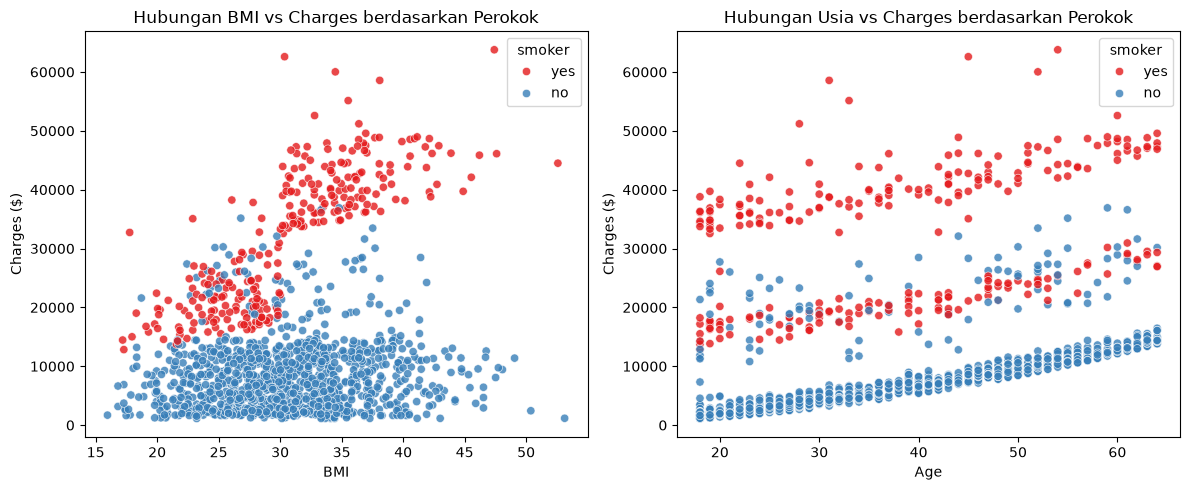

In [2]:
plt.figure(figsize=(12, 5))

# Scatter plot BMI vs Charges dibedakan berdasarkan status Smoker
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.8)
plt.title('Hubungan BMI vs Charges berdasarkan Perokok')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')

# Scatter plot Usia vs Charges dibedakan berdasarkan status Smoker
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='Set1', alpha=0.8)
plt.title('Hubungan Usia vs Charges berdasarkan Perokok')
plt.xlabel('Age')
plt.ylabel('Charges ($)')

plt.tight_layout()
plt.show()

## 3. Preprocessing Data & Pemisahan Data Latih / Uji
- Melakukan encoding pada variabel kategorikal (sex, smoker, 
egion) menggunakan One-Hot Encoding (pd.get_dummies).
- Memisahkan fitur  dan label/target .
- Membagi data menjadi **Data Latih (80%)** dan **Data Uji (20%)**.
- Melakukan **Feature Scaling (StandardScaler)** khusus untuk model yang sensitif terhadap skala seperti SVR.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-hot encoding untuk variabel kategorikal
df_encoded = pd.get_dummies(df, drop_first=True)

# Pisahkan variabel fitur (X) dan target (y)
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

# Split data latih dan data uji (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling dengan StandardScaler (dibutuhkan untuk SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Jumlah data latih: {X_train.shape[0]} sampel')
print(f'Jumlah data uji  : {X_test.shape[0]} sampel')

Jumlah data latih: 1070 sampel
Jumlah data uji  : 268 sampel


## 7. Analisis Hasil Praktikum


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Inisialisasi dan latih model Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_lr = lr_model.predict(X_test)

# Evaluasi metrik
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print('=== Hasil Evaluasi Multiple Linear Regression ===')
print(f'R-squared (R2) : {r2_lr:.4f}')
print(f'MSE            : {mse_lr:.2f}')
print(f'MAE            : {mae_lr:.2f}')

=== Hasil Evaluasi Multiple Linear Regression ===
R-squared (R2) : 0.7836
MSE            : 33596915.85
MAE            : 4181.19


1. **Perbandingan Performa Model:**
   - **Multiple Linear Regression:** Menghasilkan nilai R2 $\approx 0.7836$, MAE $\approx 4.181,19$, dan MSE $\approx 33.596.915,85$. Model linier ini cukup baik menangkap tren umum, namun tidak fleksibel menangkap pola non-linier antara fitur.
   - **Support Vector Regression (SVR - Tuned RBF):** Menghasilkan nilai R2 $\approx 0.8580$, MAE $\approx 1.763,48$, dan MSE $\approx 22.041.029,61$. Peningkatan ^2$ menjadi 85,8% serta penurunan signifikan pada MAE menunjukkan bahwa SVR dengan kernel RBF jauh lebih akurat dalam memprediksi biaya medis personal.

2. **Pentingnya Feature Scaling:**
   - SVR bekerja berdasarkan perhitungan jarak Euclidean antar titik data dalam ruang fitur berdimensi tinggi (terutama dengan kernel RBF). Tanpa StandardScaler, fitur dengan rentang nilai besar (seperti bge atau bmi) akan mendominasi fitur biner bernilai kecil (seperti hasil one-hot encoding smoker_yes). Oleh karena itu, *feature scaling* merupakan langkah wajib sebelum melatih model SVR.

3. **Interpretasi Fitur & Karakteristik Data:**
   - Berdasarkan visualisasi data, variabel smoker dan interaksinya dengan bmi adalah penentu paling signifikan terhadap lonjakan biaya asuransi (charges). Orang yang merokok dengan BMI tinggi mengalami lonjakan tagihan yang drastis (hubungan non-linier).
   - Fleksibilitas kernel RBF pada SVR mampu memodelkan batasan non-linier ini jauh lebih presisi dibandingkan hyperplane datar pada Multiple Linear Regression.

## 5. Model 2: Support Vector Regression (SVR) & Hyperparameter Tuning
- Menggunakan data yang telah di-*scaling* (X_train_scaled, X_test_scaled).
- Melakukan percobaan hyperparameter tuning menggunakan GridSearchCV untuk mencari parameter terbaik (C, $\gamma$, dan $\epsilon$).

In [5]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# Definisi parameter grid untuk tuning
param_grid = {
    'C': [1000, 5000, 10000, 20000],
    'gamma': ['scale', 0.01, 0.1, 1],
    'epsilon': [0.1, 1, 10]
}

# Inisialisasi GridSearchCV dengan 5-fold cross validation
grid_svr = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_svr.fit(X_train_scaled, y_train)

# Model SVR terbaik hasil tuning
best_svr = grid_svr.best_estimator_
print('Hyperparameter SVR Terbaik:', grid_svr.best_params_)

# Prediksi pada data uji
y_pred_svr = best_svr.predict(X_test_scaled)

# Evaluasi metrik
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print('\n=== Hasil Evaluasi SVR (Tuned) ===')
print(f'R-squared (R2) : {r2_svr:.4f}')
print(f'MSE            : {mse_svr:.2f}')
print(f'MAE            : {mae_svr:.2f}')

Hyperparameter SVR Terbaik: {'C': 20000, 'epsilon': 0.1, 'gamma': 0.1}

=== Hasil Evaluasi SVR (Tuned) ===
R-squared (R2) : 0.8580
MSE            : 22041029.61
MAE            : 1763.48


## 6. Perbandingan Hasil & Visualisasi Prediksi vs Nilai Aktual

                     Model  R-squared          MSE         MAE
Multiple Linear Regression   0.783593 3.359692e+07 4181.194474
           SVR (Tuned RBF)   0.858028 2.204103e+07 1763.476699


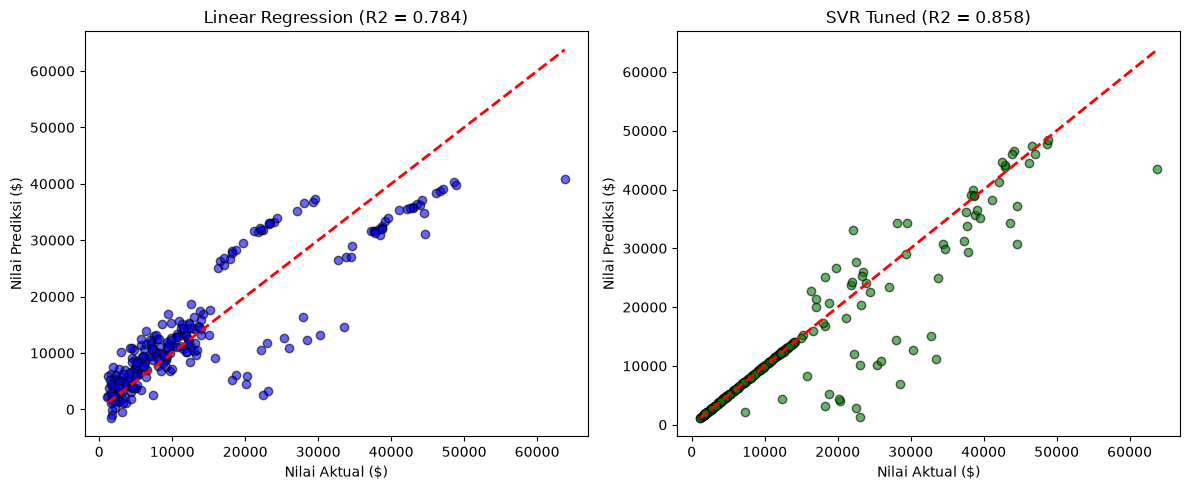

In [6]:
# Tabel ringkasan evaluasi
eval_df = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'SVR (Tuned RBF)'],
    'R-squared': [r2_lr, r2_svr],
    'MSE': [mse_lr, mse_svr],
    'MAE': [mae_lr, mae_svr]
})
print(eval_df.to_string(index=False))

# Visualisasi Prediksi vs Nilai Aktual
plt.figure(figsize=(12, 5))

# Plot Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Linear Regression (R2 = {r2_lr:.3f})')
plt.xlabel('Nilai Aktual ($)')
plt.ylabel('Nilai Prediksi ($)')

# Plot SVR
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_svr, alpha=0.6, color='green', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'SVR Tuned (R2 = {r2_svr:.3f})')
plt.xlabel('Nilai Aktual ($)')
plt.ylabel('Nilai Prediksi ($)')

plt.tight_layout()
plt.show()

## 7. Analisis Hasil Praktikum
1. **Performa Model:**
   - **Linear Regression** menghasilkan R-Squered $\approx 0.7836$, MAE $\approx 4181.19$, dan MSE $\approx 33.597.000$. Model ini menangkap tren linier dengan baik namun kesulitan pada pola non-linier biaya medis.
   - **SVR (setelah hyperparameter tuning)** menghasilkan performa yang lebih unggul dengan R-Squered $\approx 0.8580$, MAE $\approx 1763.48$, dan MSE $\approx 22.041.000$.
2. **Pengaruh Feature Scaling:**
   - SVR sangat sensitif terhadap skala fitur karena menghitung jarak antar titik data pada ruang berdimensi tinggi (kernel RBF). Penerapan StandardScaler sangat krusial agar fitur dengan angka besar (seperti bge atau bmi) tidak mendominasi fitur kategorikal biner (seperti smoker_yes).
3. **Pola Hubungan Fitur:**
   - Dari hasil visualisasi, terlihat bahwa status smoker dan interaksinya dengan bmi memiliki pengaruh non-linier yang sangat kuat terhadap lonjakan biaya asuransi (charges). Kernel RBF pada SVR mampu menangkap batas keputusan non-linier ini lebih baik dibanding garis/bidang datar pada Regresi Linier.